# 🪨 Lithology Classification from Well Logs — Beginner Session
---
**Dataset:** FORCE 2020 — North Sea wells

**Target:** LITH — Lithology class (Shale, Sandstone, Limestone, ...)

**Features:** GR · RHOB · NPHI · PEF · RDEP · DTC

**Blind well:** 16/1-2 (last well — used ONLY for final evaluation)

---
### Workflow
1. Load & inspect data
2. Clean data
3. Visualize (histogram · boxplot · log tracks · class balance)
4. Encode labels & scale features
5. Split train / validation / blind
6. Compare models (LazyPredict style)
7. Best model — detailed results
8. Blind well prediction + confusion matrix


---
## 📦 STEP 1 — Colab Setup: Upload CSV
Run this cell first to upload the CSV file.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# # ── Upload CSV to Colab ──────────────────────────────────────────────────
# from google.colab import files

# print('Please upload:  training_file.csv')
# uploaded = files.upload()
# csv_filename = list(uploaded.keys())[0]
# print(f'Uploaded: {csv_filename}')


In [6]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/SPE/Wells_Lith.csv')

# Look at the first 5 rows to see what we have
df.head()

,WELL,DEPTH_MD,GROUP,FORMATION,CALI,RDEP,RHOB,GR,NPHI,PEF,DTC,LITH
0,15/9-13,494.528,NORDLAND GP.,NaN,19.480835,1.798681,1.884186,80.200851,NaN,20.915468,161.131180,Shale
1,15/9-13,494.680,NORDLAND GP.,NaN,19.468800,1.795641,1.889794,79.262886,NaN,19.383013,160.603470,Shale
2,15/9-13,494.832,NORDLAND GP.,NaN,19.468800,1.800733,1.896523,74.821999,NaN,22.591518,160.173615,Shale
3,15/9-13,494.984,NORDLAND GP.,NaN,19.459282,1.801517,1.891913,72.878922,NaN,32.191910,160.149429,Shale
4,15/9-13,495.136,NORDLAND GP.,NaN,19.453100,1.795299,1.880034,71.729141,NaN,38.495632,160.128342,Shale


---
## 📦 STEP 2 — Import Libraries


In [9]:
# ── Data & math ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import io

# ── Plotting ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── ML: preprocessing ────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── ML: classification models ────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ── ML: evaluation ───────────────────────────────────────────────────────
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

# ── Settings ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries imported!')


All libraries imported!


---
## 📂 STEP 3 — Load & Inspect the Data


In [10]:
# ── Load CSV ─────────────────────────────────────────────────────────────
df = pd.read_csv(io.BytesIO(uploaded[csv_filename]))

print(f'Shape: {df.shape}   ({df.shape[0]:,} rows x {df.shape[1]} columns)')
print(f'\nColumns: {df.columns.tolist()}')
display(df.head())


Shape: (133198, 12)   (133,198 rows x 12 columns)

Columns: ['WELL', 'DEPTH_MD', 'GROUP', 'FORMATION', 'CALI', 'RDEP', 'RHOB', 'GR', 'NPHI', 'PEF', 'DTC', 'LITH']


,WELL,DEPTH_MD,GROUP,FORMATION,CALI,RDEP,RHOB,GR,NPHI,PEF,DTC,LITH
0,15/9-13,494.528,NORDLAND GP.,NaN,19.480835,1.798681,1.884186,80.200851,NaN,20.915468,161.131180,Shale
1,15/9-13,494.680,NORDLAND GP.,NaN,19.468800,1.795641,1.889794,79.262886,NaN,19.383013,160.603470,Shale
2,15/9-13,494.832,NORDLAND GP.,NaN,19.468800,1.800733,1.896523,74.821999,NaN,22.591518,160.173615,Shale
3,15/9-13,494.984,NORDLAND GP.,NaN,19.459282,1.801517,1.891913,72.878922,NaN,32.191910,160.149429,Shale
4,15/9-13,495.136,NORDLAND GP.,NaN,19.453100,1.795299,1.880034,71.729141,NaN,38.495632,160.128342,Shale


In [11]:
# ── Class distribution — how many samples per lithology? ─────────────────
print('Lithology class counts:')
print(df['LITH'].value_counts())

print('\nWells in dataset:')
print(df['WELL'].value_counts())

print('\nMissing values per column:')
print(df.isnull().sum())


Lithology class counts:
LITH
Shale              82390
Sandstone          15794
Limestone          11912
Sandstone/Shale     6573
Chalk               5129
Marl                4968
Halite              4314
Tuff                1498
Anhydrite            374
Dolomite             188
Coal                  58
Name: count, dtype: int64

Wells in dataset:
WELL
15/9-13        18270
15/9-15        17717
16/10-1        17675
15/9-17        17350
16/10-3        15956
16/11-1 ST3    14938
16/2-11 A      10708
16/2-16        10025
16/1-6 A        3623
16/10-5         2765
16/10-2         2437
16/1-2          1734
Name: count, dtype: int64

Missing values per column:
WELL             0
DEPTH_MD         0
GROUP            0
FORMATION    21566
CALI           192
RDEP          7393
RHOB         25145
GR               0
NPHI         41473
PEF          32358
DTC            563
LITH             0
dtype: int64


---
## 🧹 STEP 4 — Clean Data
Select the 6 log features + target, drop NaN rows, apply physical range filters.
We use **15/9-13** as the blind well — it is separated BEFORE cleaning.


In [12]:
# ── Define features and target ───────────────────────────────────────────
FEATURES = ['GR', 'RHOB', 'NPHI', 'PEF', 'RDEP', 'DTC']
TARGET   = 'LITH'

# ── Separate blind well FIRST (before any processing) ────────────────────
# Well 15/9-13 is our blind well — never used for training
BLIND_WELL = '15/9-13'
df_blind_raw = df[df['WELL'] == BLIND_WELL].copy()
df_train_raw = df[df['WELL'] != BLIND_WELL].copy()

print(f'Training wells rows : {len(df_train_raw):,}')
print(f'Blind well rows     : {len(df_blind_raw):,}')


Training wells rows : 114,928
Blind well rows     : 18,270


In [13]:
# ── Keep only needed columns, drop NaN, apply range filters ──────────────

def clean_well_data(df_in):
    # Keep only feature + target columns
    df_out = df_in[FEATURES + [TARGET, 'WELL', 'DEPTH_MD']].copy()

    # Drop rows where any feature or target is NaN
    df_out = df_out.dropna(subset=FEATURES + [TARGET])

    # Physical range filters (remove unrealistic sensor readings)
    df_out = df_out[(df_out['GR']   >=   0) & (df_out['GR']   <= 200)]
    df_out = df_out[(df_out['RHOB'] >= 1.5) & (df_out['RHOB'] <= 3.5)]
    df_out = df_out[(df_out['NPHI'] >=-0.1) & (df_out['NPHI'] <= 1.0)]
    df_out = df_out[(df_out['PEF']  >=   0) & (df_out['PEF']  <=  10)]
    df_out = df_out[(df_out['RDEP'] >= 0.1) & (df_out['RDEP'] <=2000)]
    df_out = df_out[(df_out['DTC']  >=  40) & (df_out['DTC']  <= 250)]

    return df_out.reset_index(drop=True)

df_train = clean_well_data(df_train_raw)
df_blind = clean_well_data(df_blind_raw)

print(f'Training rows after cleaning : {len(df_train):,}')
print(f'Blind rows after cleaning    : {len(df_blind):,}')
print('\nTraining class distribution:')
print(df_train[TARGET].value_counts())


Training rows after cleaning : 67,858
Blind rows after cleaning    : 11,927

Training class distribution:
LITH
Shale              39696
Limestone           9377
Sandstone           8262
Sandstone/Shale     4145
Marl                3127
Chalk               2166
Tuff                 861
Dolomite              98
Anhydrite             75
Coal                  51
Name: count, dtype: int64


---
## 📊 STEP 5 — Exploratory Visualization


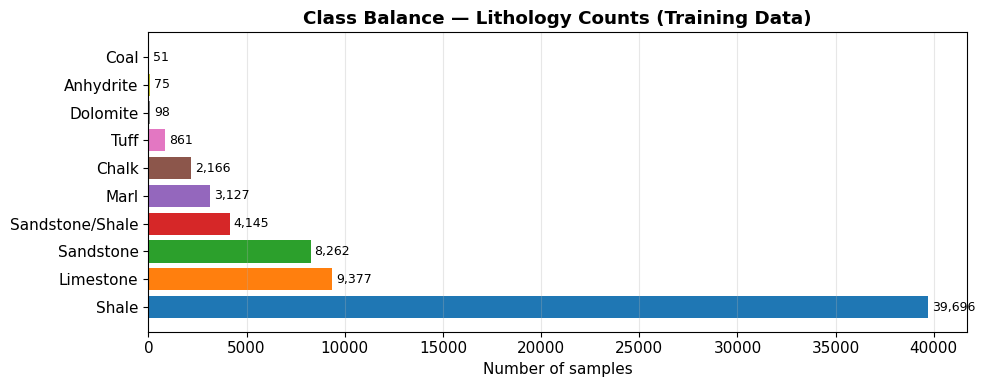

Notice: Shale dominates the dataset — this is a class imbalance problem


In [14]:
# ── 5.1 Class balance bar chart ──────────────────────────────────────────
# Important for classification — imbalanced classes can bias the model

class_counts = df_train[TARGET].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(class_counts.index, class_counts.values,
               color=plt.cm.tab10.colors[:len(class_counts)])
ax.set_xlabel('Number of samples')
ax.set_title('Class Balance — Lithology Counts (Training Data)', fontweight='bold')

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print('Notice: Shale dominates the dataset — this is a class imbalance problem')


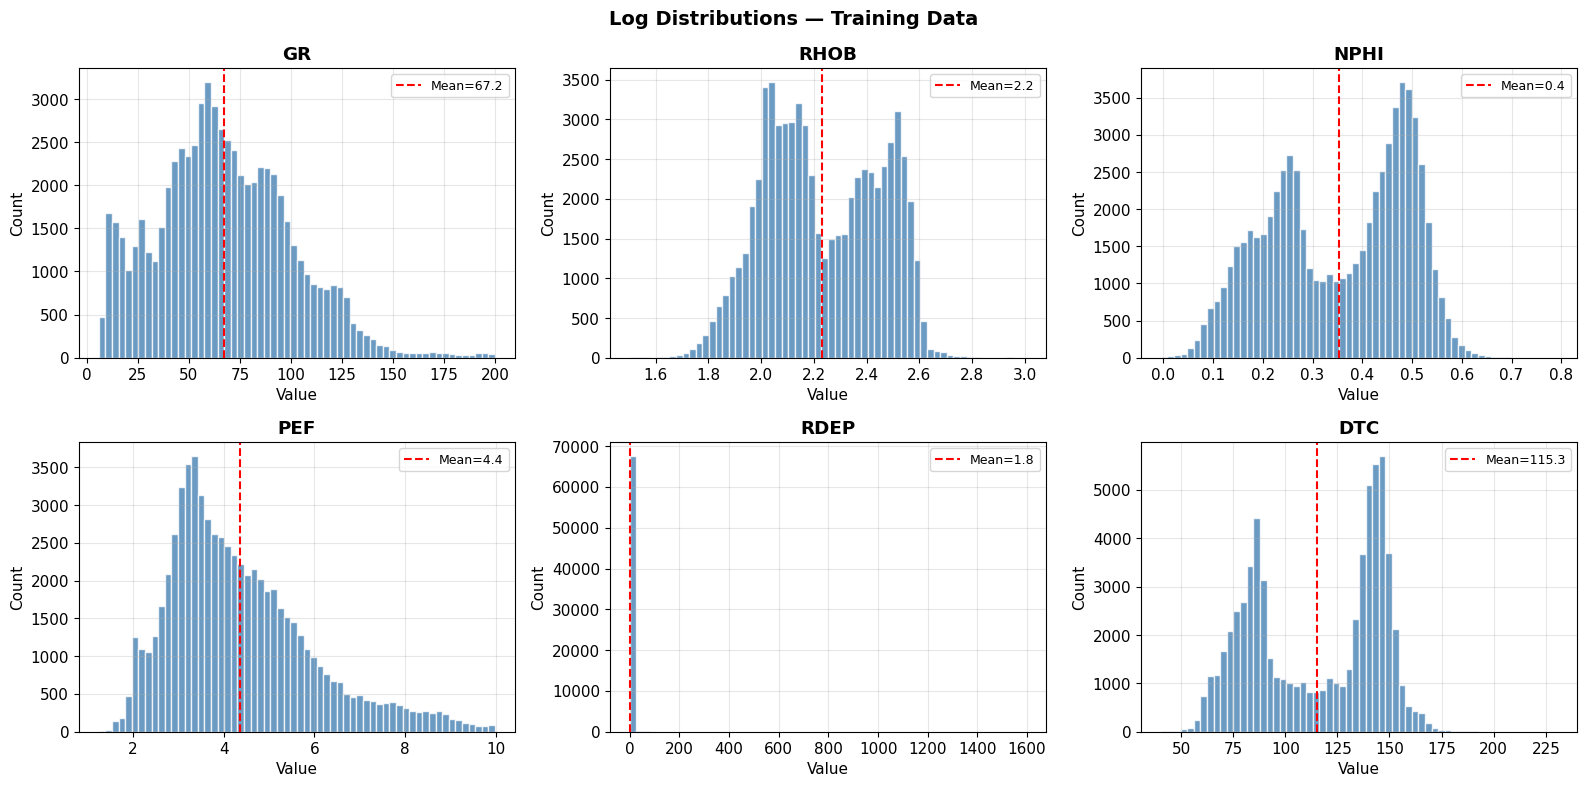

In [15]:
# ── 5.2 Histograms — distribution of each log ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Log Distributions — Training Data', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    data = df_train[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='red', ls='--', lw=1.5,
                    label=f'Mean={data.mean():.1f}')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


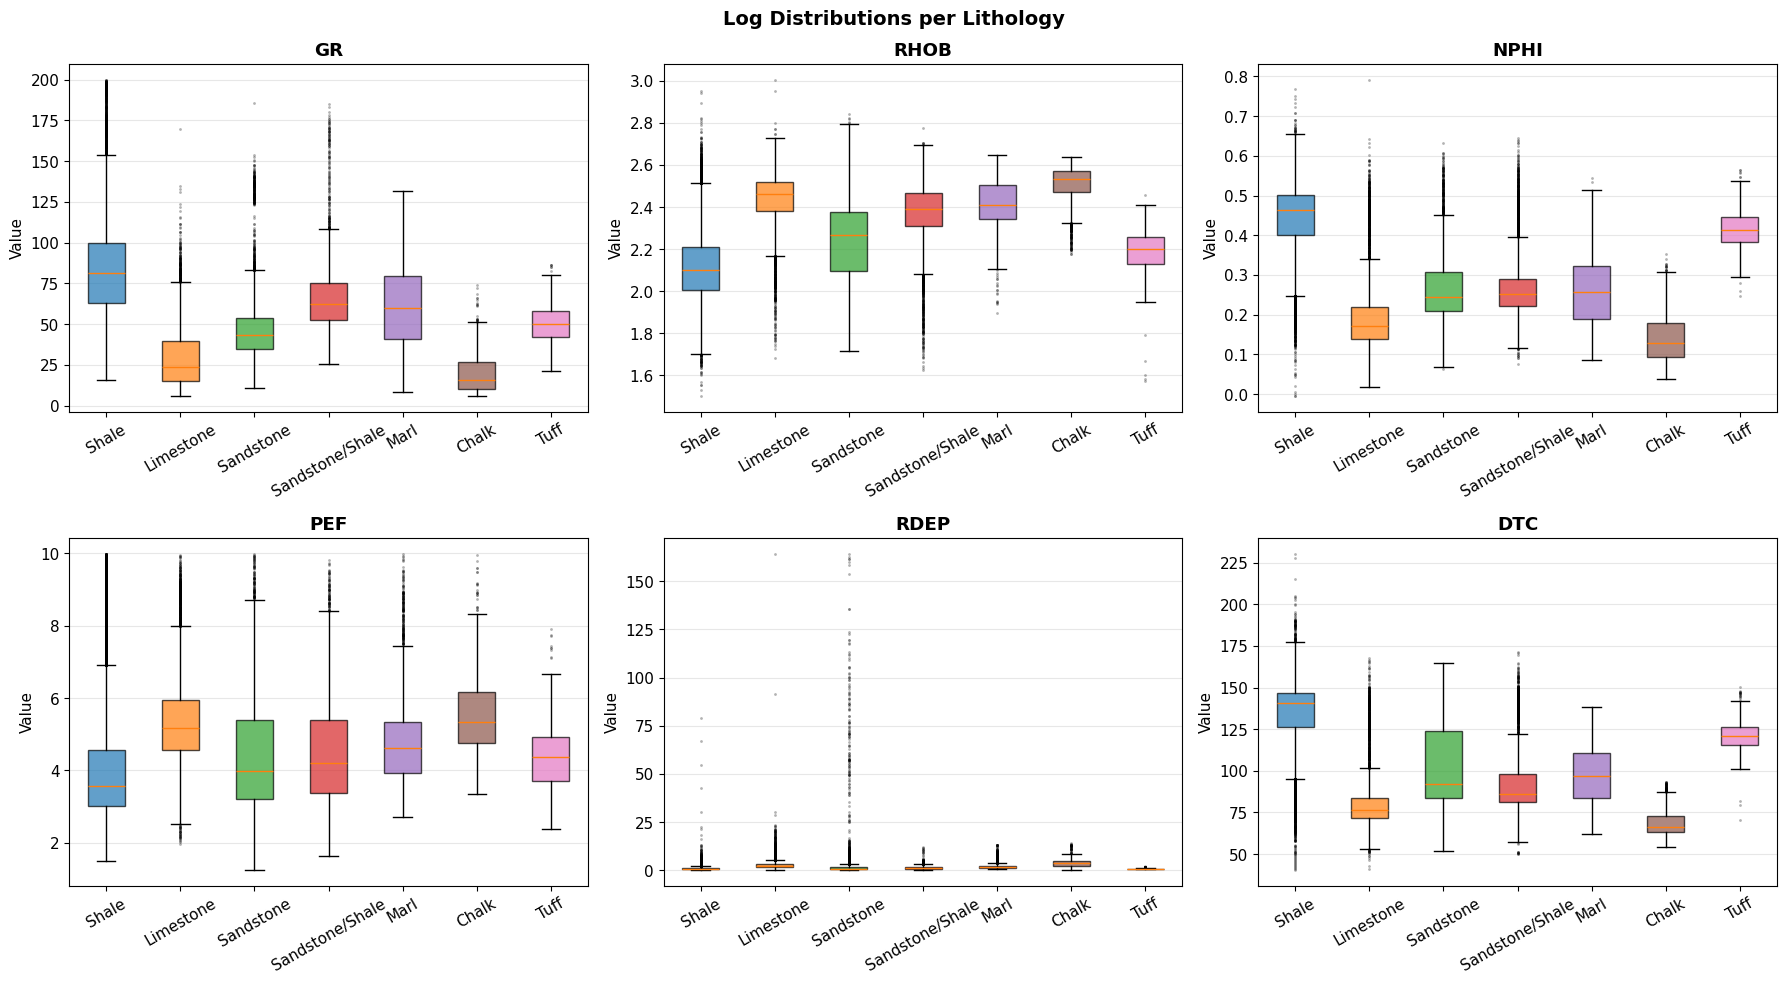

Key insight: GR and RHOB are usually the best separators for lithology


In [16]:
# ── 5.3 Boxplot — log distributions per lithology ────────────────────────
# This is the MOST useful plot for classification:
# It shows how each lithology separates in log space

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Log Distributions per Lithology', fontsize=14, fontweight='bold')
axes = axes.flatten()

# Only plot lithologies with enough samples
main_liths = df_train[TARGET].value_counts()[lambda x: x > 100].index.tolist()
df_main = df_train[df_train[TARGET].isin(main_liths)]

for i, col in enumerate(FEATURES):
    ax = axes[i]
    # Group data by lithology
    data_per_lith = [df_main[df_main[TARGET] == lith][col].dropna().values
                     for lith in main_liths]

    bp = ax.boxplot(data_per_lith, labels=main_liths, patch_artist=True,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))

    # Color each lithology box differently
    colors = plt.cm.tab10.colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('Key insight: GR and RHOB are usually the best separators for lithology')


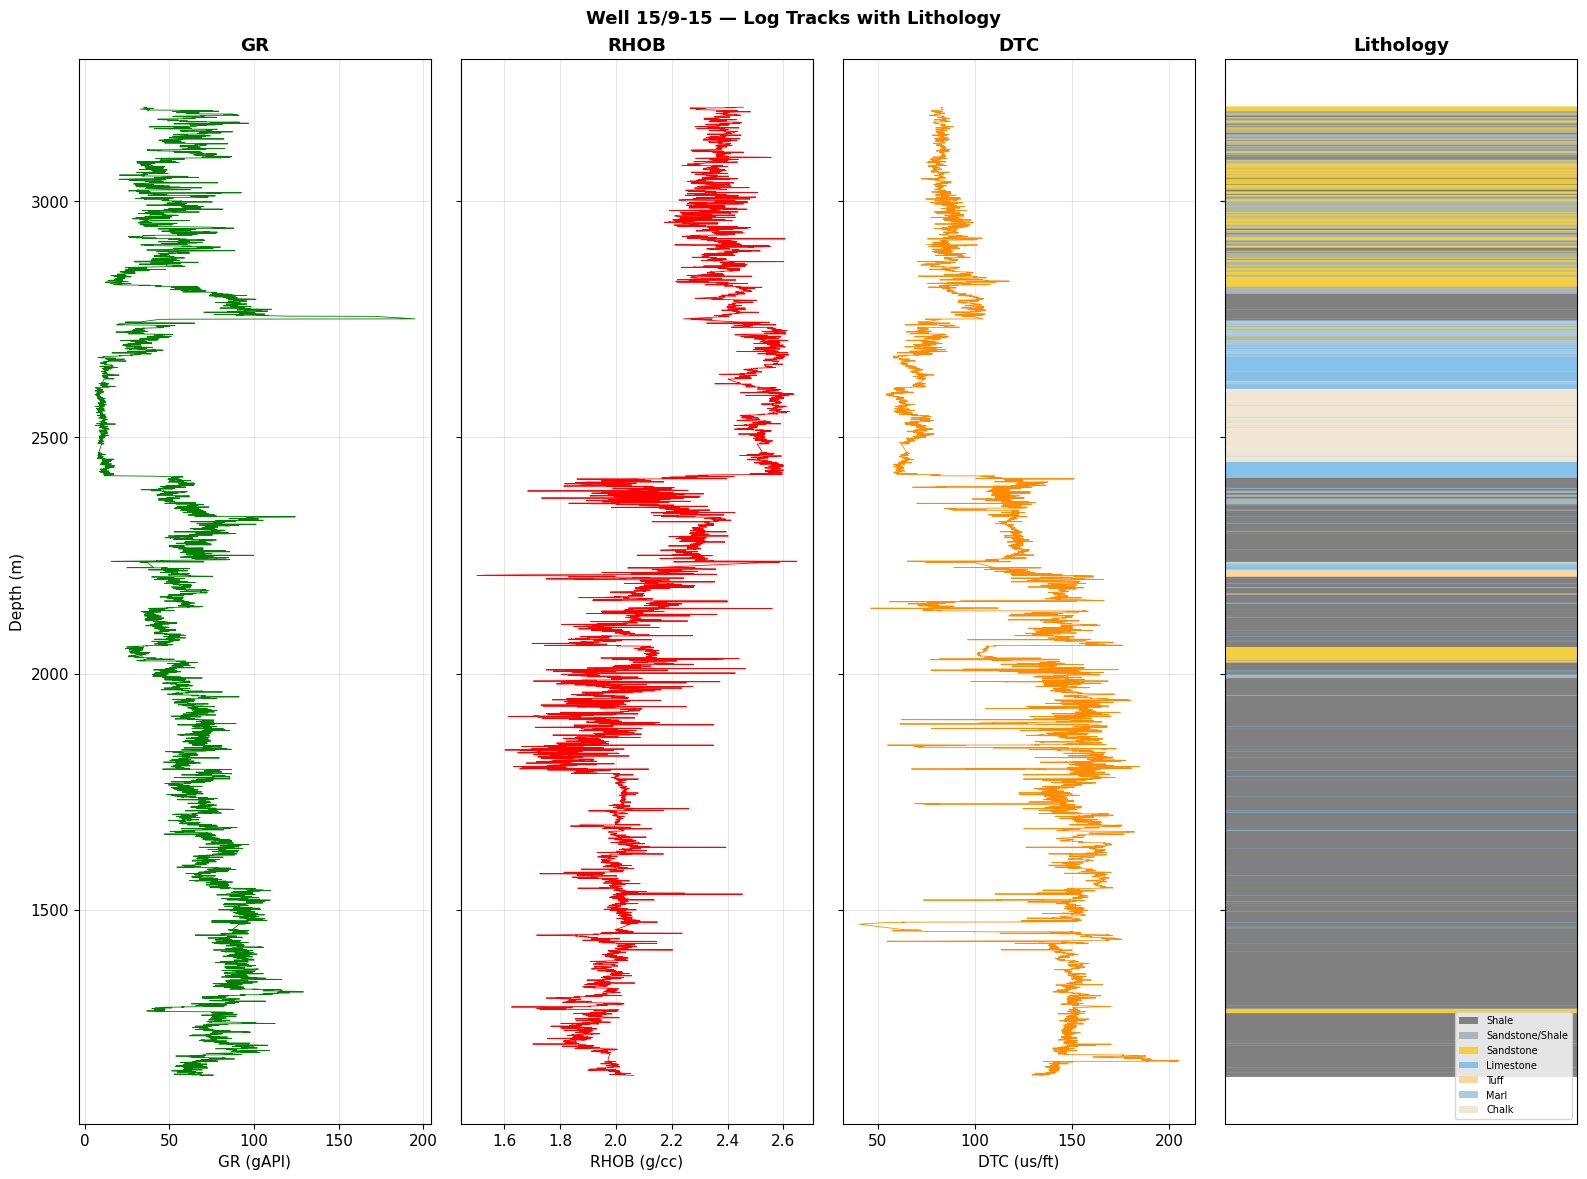

In [17]:
# ── 5.4 Log Track — one well with lithology color fill ───────────────────
# Pick one well to display as classic log tracks

# Define a color for each lithology class
lith_colors = {
    'Shale':           '#808080',
    'Sandstone':       '#F4D03F',
    'Sandstone/Shale': '#AAB7B8',
    'Limestone':       '#85C1E9',
    'Chalk':           '#F0E6D3',
    'Marl':            '#A9CCE3',
    'Halite':          '#F8C471',
    'Anhydrite':       '#D7BDE2',
    'Dolomite':        '#A3E4D7',
    'Tuff':            '#FAD7A0',
    'Coal':            '#2C3E50',
}

df_plot = df_train[df_train['WELL'] == '15/9-15'].copy()
depth   = df_plot['DEPTH_MD'].values

fig, axes = plt.subplots(1, 4, figsize=(16, 12), sharey=True)
fig.suptitle('Well 15/9-15 — Log Tracks with Lithology', fontsize=13, fontweight='bold')

# Track 1: GR
axes[0].plot(df_plot['GR'], depth, 'green', lw=0.6)
axes[0].set_xlabel('GR (gAPI)'); axes[0].set_title('GR', fontweight='bold')
axes[0].set_ylabel('Depth (m)'); axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3)

# Track 2: RHOB
axes[1].plot(df_plot['RHOB'], depth, 'red', lw=0.6)
axes[1].set_xlabel('RHOB (g/cc)'); axes[1].set_title('RHOB', fontweight='bold')
axes[1].invert_yaxis(); axes[1].grid(True, alpha=0.3)

# Track 3: DTC
axes[2].plot(df_plot['DTC'], depth, 'darkorange', lw=0.6)
axes[2].set_xlabel('DTC (us/ft)'); axes[2].set_title('DTC', fontweight='bold')
axes[2].invert_yaxis(); axes[2].grid(True, alpha=0.3)

# Track 4: Lithology color bar
ax = axes[3]
ax.set_title('Lithology', fontweight='bold')
# Plot colored blocks for each depth sample
for j in range(len(df_plot) - 1):
    lith = df_plot[TARGET].iloc[j]
    color = lith_colors.get(lith, 'white')
    d_top = depth[j]
    d_bot = depth[j+1]
    ax.fill_betweenx([d_top, d_bot], 0, 1, color=color, alpha=0.9)

# Legend
from matplotlib.patches import Patch
liths_present = df_plot[TARGET].unique()
legend_elements = [Patch(facecolor=lith_colors.get(l, 'white'), label=l)
                   for l in liths_present]
ax.legend(handles=legend_elements, loc='lower right', fontsize=7)
ax.set_xlim(0, 1); ax.set_xticks([])
ax.invert_yaxis(); ax.grid(False)

plt.tight_layout()
plt.show()


---
## ⚙️ STEP 6 — Label Encoding & Feature Scaling
**Label encoding:** Converts text class names → numbers (required by sklearn)

- Shale → 0, Sandstone → 1, etc.

**StandardScaler:** Normalizes each feature to mean=0, std=1


In [18]:
# ── Extract arrays ───────────────────────────────────────────────────────
X_train_full = df_train[FEATURES].values
X_blind      = df_blind[FEATURES].values

# ── Encode lithology labels: text → integer ───────────────────────────────
# LabelEncoder learns the mapping from the training data
le = LabelEncoder()
le.fit(df_train[TARGET])            # learn class names from training data

y_train_full = le.transform(df_train[TARGET])  # convert train labels
y_blind      = le.transform(df_blind[TARGET])  # convert blind labels (same mapping)

# Print the mapping so we know which number = which lithology
print('Label encoding mapping:')
for i, name in enumerate(le.classes_):
    print(f'  {i:2d} = {name}')

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
scaler.fit(X_train_full)                         # fit on training data ONLY
X_train_scaled = scaler.transform(X_train_full)
X_blind_scaled = scaler.transform(X_blind)       # same scaler on blind well

print(f'\nTraining set : {X_train_scaled.shape}')
print(f'Blind well   : {X_blind_scaled.shape}')


Label encoding mapping:
   0 = Anhydrite
   1 = Chalk
   2 = Coal
   3 = Dolomite
   4 = Limestone
   5 = Marl
   6 = Sandstone
   7 = Sandstone/Shale
   8 = Shale
   9 = Tuff

Training set : (67858, 6)
Blind well   : (11927, 6)


---
## ✂️ STEP 7 — Train / Validation Split
80% of training data for learning, 20% for checking during model comparison.
Blind well (15/9-13) stays completely separate.


In [19]:
# ── 80% train / 20% validation ───────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X_train_scaled,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full    # keep same class % in both splits
)

print(f'Train      : {X_train.shape[0]:,} rows')
print(f'Validation : {X_val.shape[0]:,} rows')
print(f'Blind well : {X_blind_scaled.shape[0]:,} rows')


Train      : 54,286 rows
Validation : 13,572 rows
Blind well : 11,927 rows


---
## 🏃 STEP 8 — Model Comparison (LazyPredict Style)
We train 7 classifiers and rank them by **Accuracy** and **F1 Score** on the validation set.

**F1 score** is better than accuracy when classes are imbalanced (like here — lots of Shale).


In [20]:
# ── Define models to compare ─────────────────────────────────────────────
models_to_test = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Naive Bayes',         GaussianNB()),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',       DecisionTreeClassifier(random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('XG Boost',            XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100, random_state=42)),
]

# ── Train each model and record performance ───────────────────────────────
results = []

for model_name, model in models_to_test:
    print(f'Training: {model_name}...', end=' ')

    model.fit(X_train, y_train)          # train
    y_pred = model.predict(X_val)        # predict on validation set

    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='weighted')   # weighted = accounts for class imbalance

    results.append({'Model': model_name, 'Accuracy': round(acc, 4),
                    'F1 (weighted)': round(f1, 4), 'object': model})

    print(f'Accuracy={acc:.4f}  F1={f1:.4f}')

print('\nAll models trained!')


Training: Logistic Regression... Accuracy=0.7871  F1=0.7584
Training: Naive Bayes... Accuracy=0.6496  F1=0.6414
Training: K-Nearest Neighbors... Accuracy=0.8935  F1=0.8913
Training: Decision Tree... Accuracy=0.8691  F1=0.8689
Training: Random Forest... Accuracy=0.9137  F1=0.9108
Training: XG Boost... Accuracy=0.8999  F1=0.8974
Training: Gradient Boosting... Accuracy=0.8601  F1=0.8535

All models trained!


In [21]:
# ── Show ranked results ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).drop(columns=['object'])
results_df = results_df.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
results_df.index += 1

print('MODEL COMPARISON — Ranked by F1 Score (Validation Set)')
display(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')


MODEL COMPARISON — Ranked by F1 Score (Validation Set)


,Model,Accuracy,F1 (weighted)
1,Random Forest,0.9137,0.9108
2,XG Boost,0.8999,0.8974
3,K-Nearest Neighbors,0.8935,0.8913
4,Decision Tree,0.8691,0.8689
5,Gradient Boosting,0.8601,0.8535
6,Logistic Regression,0.7871,0.7584
7,Naive Bayes,0.6496,0.6414



Best model: Random Forest


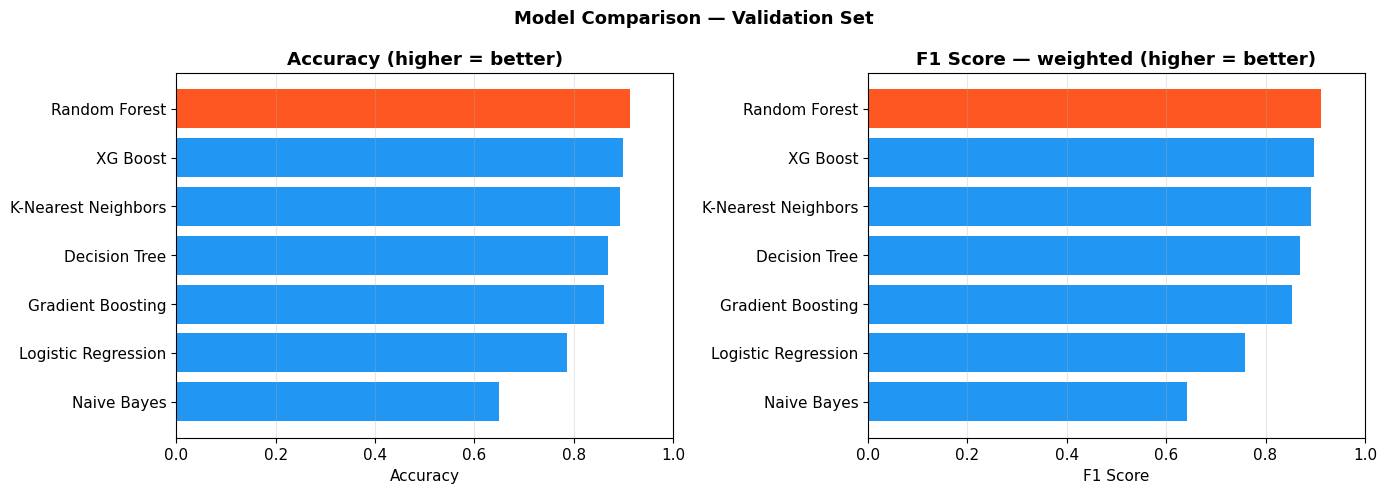

Red bar = Random Forest (best model)


In [22]:
# ── Bar chart comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Validation Set', fontsize=13, fontweight='bold')

plot_df = results_df.sort_values('F1 (weighted)', ascending=True)
colors  = ['#FF5722' if n == best_model_name else '#2196F3' for n in plot_df['Model']]

axes[0].barh(plot_df['Model'], plot_df['Accuracy'], color=colors)
axes[0].set_title('Accuracy (higher = better)', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1)
axes[0].grid(True, axis='x', alpha=0.3)

axes[1].barh(plot_df['Model'], plot_df['F1 (weighted)'], color=colors)
axes[1].set_title('F1 Score — weighted (higher = better)', fontweight='bold')
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim(0, 1)
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Red bar = {best_model_name} (best model)')


---
## 🔬 STEP 9 — Best Model: Detailed Training
Retrain on all training data, check feature importance and classification report.


In [23]:
# ── Retrieve the best model object ───────────────────────────────────────
best_model = None
for entry in results:
    if entry['Model'] == best_model_name:
        best_model = entry['object']
        break

# ── Retrain on ALL training data (train + val combined) ───────────────────
X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

print(f'Retraining {best_model_name} on {len(X_all):,} samples...')
best_model.fit(X_all, y_all)
print('Done!')


Retraining Random Forest on 67,858 samples...
Done!


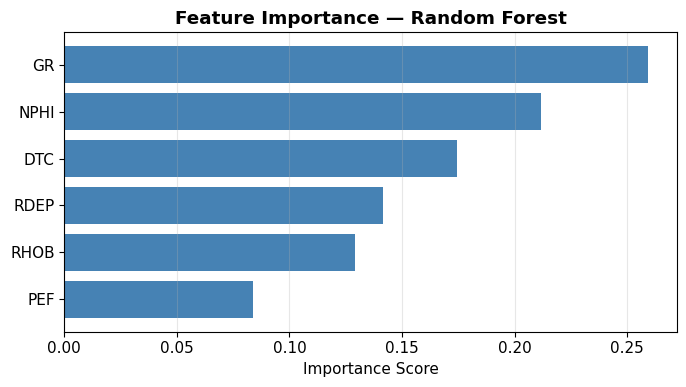

In [24]:
# ── Feature Importance (tree-based models only) ───────────────────────────
if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({'Feature': FEATURES,
                            'Importance': best_model.feature_importances_})
    imp_df = imp_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    ax.set_title(f'Feature Importance — {best_model_name}', fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'{best_model_name} does not have feature_importances_')


---
## 🧪 STEP 10 — Blind Well Prediction & Evaluation
Final test on **well 15/9-13** — the model has never seen this well.


In [25]:
# ── Predict lithology on blind well ──────────────────────────────────────
y_blind_pred = best_model.predict(X_blind_scaled)

# Convert numeric labels back to lithology names for readability
y_blind_names = le.inverse_transform(y_blind)
y_pred_names  = le.inverse_transform(y_blind_pred)

acc_b = accuracy_score(y_blind, y_blind_pred)
f1_b  = f1_score(y_blind, y_blind_pred, average='weighted')

print('=' * 50)
print(f'  BLIND WELL (15/9-13) — Final Results')
print('=' * 50)
print(f'  Model    : {best_model_name}')
print(f'  Accuracy : {acc_b:.4f}  ({acc_b*100:.1f}%)')
print(f'  F1 Score : {f1_b:.4f}')
print('=' * 50)


  BLIND WELL (16/1-2) — Final Results
  Model    : Random Forest
  Accuracy : 0.7910  (79.1%)
  F1 Score : 0.7662


In [26]:
# ── Classification Report ─────────────────────────────────────────────────
# Shows precision, recall, and F1 for EACH lithology class separately
# precision = of all samples predicted as Shale, how many were really Shale?
# recall    = of all real Shale samples, how many did the model catch?

print('Classification Report — Blind Well (16/1-2):')
print(classification_report(y_blind_names, y_pred_names, zero_division=0))


Classification Report — Blind Well (16/1-2):
                 precision    recall  f1-score   support

          Chalk       0.00      0.00      0.00         0
      Limestone       0.78      0.81      0.79      1409
           Marl       0.42      0.30      0.35       419
      Sandstone       0.84      0.28      0.43      1544
Sandstone/Shale       0.07      0.02      0.03       351
          Shale       0.83      0.96      0.89      8031
           Tuff       0.27      0.23      0.25       173

       accuracy                           0.79     11927
      macro avg       0.46      0.37      0.39     11927
   weighted avg       0.78      0.79      0.77     11927



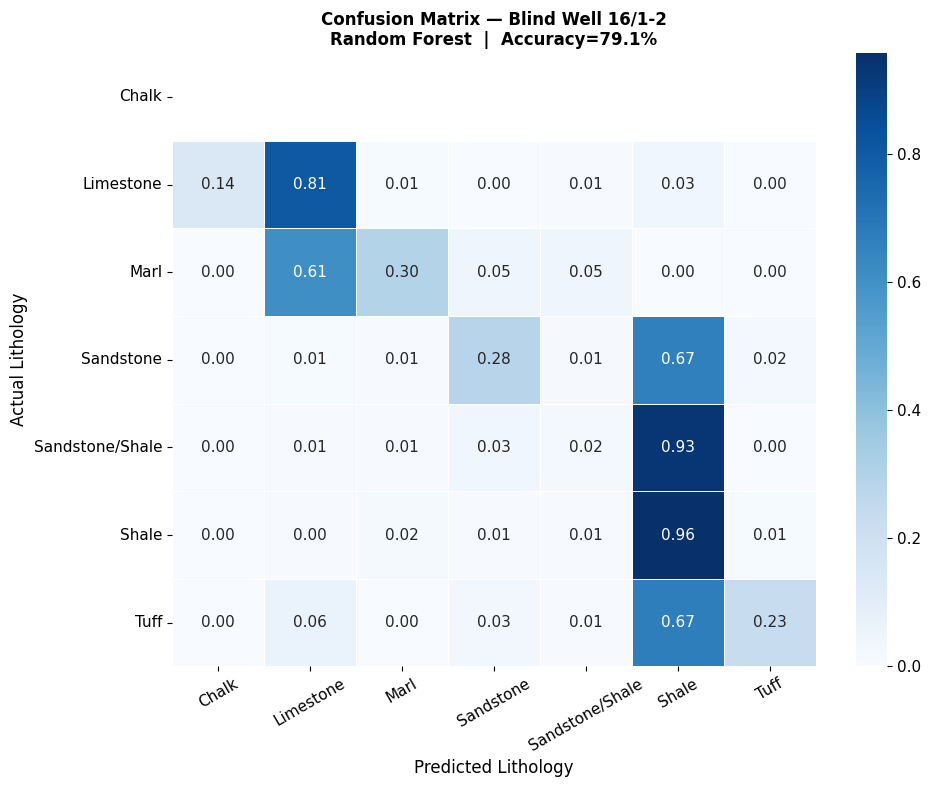

Diagonal = correct predictions (darker blue = better)
Off-diagonal = where the model confused one lithology for another


In [27]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
# Rows = actual lithology
# Columns = predicted lithology
# Diagonal = correct predictions
# Off-diagonal = wrong predictions (confusion between classes)

# Get the unique classes present in blind well
present_classes = sorted(set(y_blind_names) | set(y_pred_names))

cm = confusion_matrix(y_blind_names, y_pred_names, labels=present_classes)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot heatmap: normalize by row (shows % of each actual class predicted correctly)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True,                  # show numbers in each cell
    fmt='.2f',                   # 2 decimal places
    cmap='Blues',                # blue = high values
    xticklabels=present_classes,
    yticklabels=present_classes,
    linewidths=0.5,
    ax=ax
)

ax.set_xlabel('Predicted Lithology', fontsize=12)
ax.set_ylabel('Actual Lithology', fontsize=12)
ax.set_title(f'Confusion Matrix — Blind Well 16/1-2\n{best_model_name}  |  Accuracy={acc_b*100:.1f}%',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('Diagonal = correct predictions (darker blue = better)')
print('Off-diagonal = where the model confused one lithology for another')


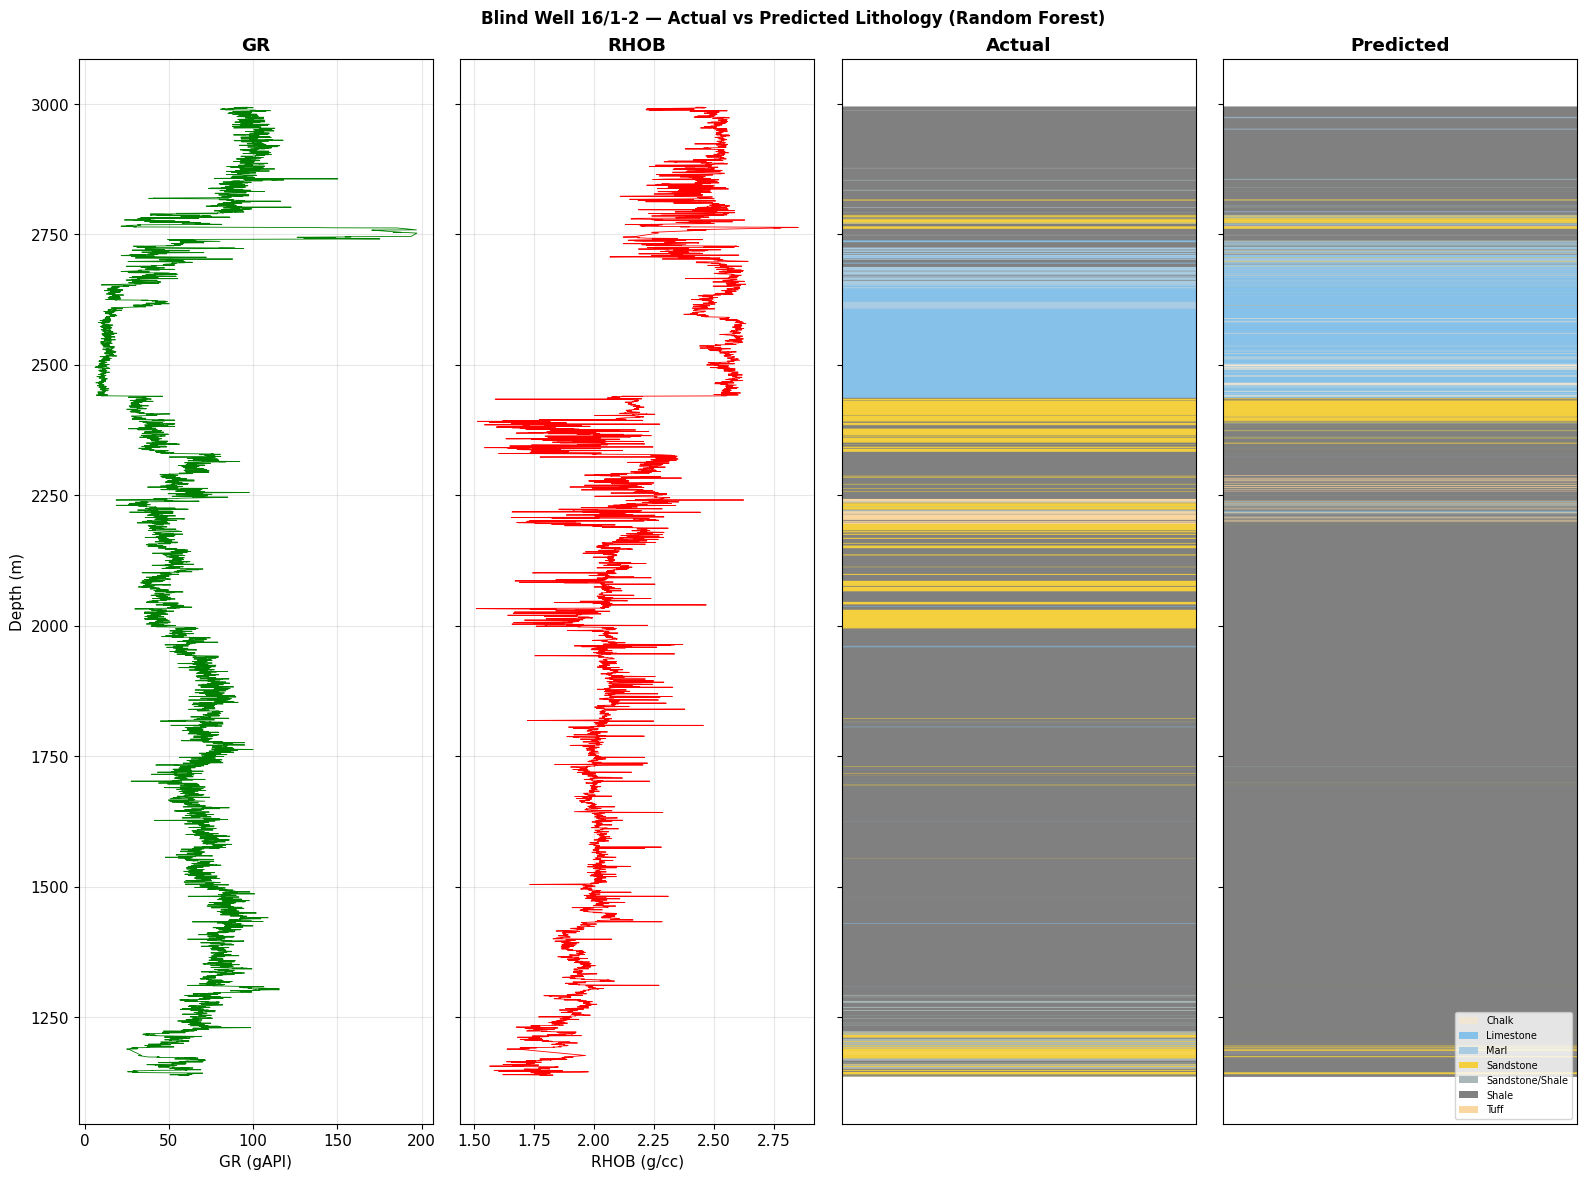

Left color column = actual lithology | Right = what the model predicted


In [28]:
# ── Log track: Actual vs Predicted lithology vs depth ────────────────────
depth_blind = df_blind['DEPTH_MD'].values

fig, axes = plt.subplots(1, 4, figsize=(16, 12), sharey=True)
fig.suptitle(f'Blind Well 16/1-2 — Actual vs Predicted Lithology ({best_model_name})',
             fontsize=12, fontweight='bold')

# Track 1: GR
axes[0].plot(df_blind['GR'], depth_blind, 'green', lw=0.6)
axes[0].set_xlabel('GR (gAPI)'); axes[0].set_title('GR', fontweight='bold')
axes[0].set_ylabel('Depth (m)'); axes[0].invert_yaxis(); axes[0].grid(True, alpha=0.3)

# Track 2: RHOB
axes[1].plot(df_blind['RHOB'], depth_blind, 'red', lw=0.6)
axes[1].set_xlabel('RHOB (g/cc)'); axes[1].set_title('RHOB', fontweight='bold')
axes[1].invert_yaxis(); axes[1].grid(True, alpha=0.3)

# Track 3: Actual Lithology
ax = axes[2]
ax.set_title('Actual', fontweight='bold')
for j in range(len(df_blind) - 1):
    lith  = y_blind_names[j]
    color = lith_colors.get(lith, 'white')
    ax.fill_betweenx([depth_blind[j], depth_blind[j+1]], 0, 1, color=color, alpha=0.9)
ax.set_xlim(0, 1); ax.set_xticks([])
ax.invert_yaxis(); ax.grid(False)

# Track 4: Predicted Lithology
ax = axes[3]
ax.set_title('Predicted', fontweight='bold')
for j in range(len(df_blind) - 1):
    lith  = y_pred_names[j]
    color = lith_colors.get(lith, 'white')
    ax.fill_betweenx([depth_blind[j], depth_blind[j+1]], 0, 1, color=color, alpha=0.9)

# Shared legend
from matplotlib.patches import Patch
all_liths = sorted(set(y_blind_names) | set(y_pred_names))
legend_elements = [Patch(facecolor=lith_colors.get(l, 'white'), label=l) for l in all_liths]
ax.legend(handles=legend_elements, loc='lower right', fontsize=7)
ax.set_xlim(0, 1); ax.set_xticks([])
ax.invert_yaxis(); ax.grid(False)

plt.tight_layout()
plt.show()
print('Left color column = actual lithology | Right = what the model predicted')


---
## 📊 STEP 11 — Final Summary


In [29]:
# ── Print full summary ────────────────────────────────────────────────────
print('=' * 60)
print('          SESSION SUMMARY — LITHOLOGY CLASSIFICATION')
print('=' * 60)
print(f'  Features       : {FEATURES}')
print(f'  Target         : LITH ({len(le.classes_)} classes)')
print(f'  Classes        : {list(le.classes_)}')
print(f'  Blind well     : {BLIND_WELL}')
print(f'  Training rows  : {len(X_all):,}')
print(f'  Blind rows     : {len(X_blind_scaled):,}')
print('\n  ALL MODELS RANKED:')
display(results_df)
print(f'\n  BEST MODEL ON BLIND WELL:')
print(f'  Model    : {best_model_name}')
print(f'  Accuracy : {acc_b*100:.1f}%')
print(f'  F1 Score : {f1_b:.4f}')
print('=' * 60)


          SESSION SUMMARY — LITHOLOGY CLASSIFICATION
  Features       : ['GR', 'RHOB', 'NPHI', 'PEF', 'RDEP', 'DTC']
  Target         : LITH (10 classes)
  Classes        : ['Anhydrite', 'Chalk', 'Coal', 'Dolomite', 'Limestone', 'Marl', 'Sandstone', 'Sandstone/Shale', 'Shale', 'Tuff']
  Blind well     : 15/9-13
  Training rows  : 67,858
  Blind rows     : 11,927

  ALL MODELS RANKED:


,Model,Accuracy,F1 (weighted)
1,Random Forest,0.9137,0.9108
2,XG Boost,0.8999,0.8974
3,K-Nearest Neighbors,0.8935,0.8913
4,Decision Tree,0.8691,0.8689
5,Gradient Boosting,0.8601,0.8535
6,Logistic Regression,0.7871,0.7584
7,Naive Bayes,0.6496,0.6414



  BEST MODEL ON BLIND WELL:
  Model    : Random Forest
  Accuracy : 79.1%
  F1 Score : 0.7662


---
## Key Takeaways
| Concept | What we learned |
|---------|----------------|
| Classification vs Regression | Here we predict a **category** (rock type), not a number |
| Class imbalance | Shale dominates — F1 score is fairer than accuracy |
| Label Encoding | Converts text labels → numbers for sklearn |
| Stratified split | Keeps same class % in train and val splits |
| Confusion matrix | Shows which lithologies the model confuses with each other |
| Precision | Of all predicted Shale → how many really are Shale? |
| Recall | Of all real Shale → how many did the model find? |
| F1 Score | Balance between precision and recall |
| Blind well track | Visual comparison of actual vs predicted lithology by depth |
